In [2]:
#Carga y Limpieza
import pandas as pd
import numpy as np
from pathlib import Path

print("1. Cargando y limpiando datos...")
BASE_DIR = Path().resolve().parent
ruta_datos = BASE_DIR / 'data' / 'Dataset_Smart_Farming_base.csv'
df = pd.read_csv(ruta_datos)

# Limpieza básica
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
df_limpio = df.dropna(subset=['crop_disease_status']).copy()
df_limpio['irrigation_type'] = df_limpio['irrigation_type'].fillna('Desconocido')

# Separar características (X) y respuesta (y)
y = df_limpio['crop_disease_status']
columnas_irrelevantes = ['farm_id', 'sensor_id', 'timestamp', 'sowing_date', 'harvest_date', 'latitude', 'longitude']
X = df_limpio.drop(columns=columnas_irrelevantes + ['crop_disease_status'])
print(" Datos listos.")

1. Cargando y limpiando datos...
 Datos listos.


In [3]:
# Preprocesamiento y Balanceo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

print("2. Procesando y balanceando clases...")
# División Train/Test (70/30)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Definir transformaciones
variables_categoricas = ['region', 'crop_type', 'irrigation_type', 'fertilizer_type']
variables_numericas = [col for col in X.columns if col not in variables_categoricas]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), variables_numericas),
    ('cat', OneHotEncoder(handle_unknown='ignore'), variables_categoricas)
])

# Aplicar transformaciones
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

# Aplicar SMOTE para balancear enfermedades raras
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_processed, y_train)
print(" Datos procesados y balanceados.")

2. Procesando y balanceando clases...
 Datos procesados y balanceados.


3. Entrenando Random Forest...
 Precisión Global (Accuracy): 98.20%

--- REPORTE DETALLADO POR CLASE ---
              precision    recall  f1-score   support

        Mild       0.97      0.97      0.97       188
    Moderate       0.97      0.97      0.97       168
      Severe       1.00      1.00      1.00       199

    accuracy                           0.98       555
   macro avg       0.98      0.98      0.98       555
weighted avg       0.98      0.98      0.98       555



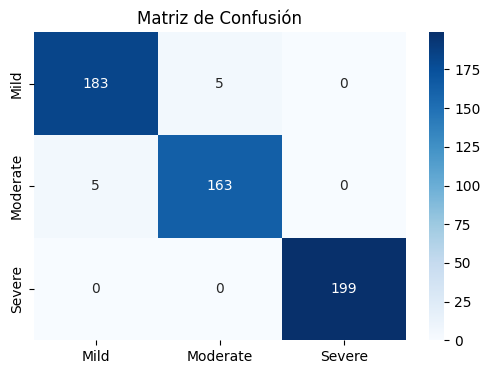

In [4]:
#Entrenamiento y Examen
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("3. Entrenando Random Forest...")
# Crear y entrenar el modelo
modelo_guardian = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_guardian.fit(X_resampled, y_resampled)

# Tomar examen final
y_pred = modelo_guardian.predict(X_test_processed)

# Resultados
precision = accuracy_score(y_test, y_pred)
print(f" Precisión Global (Accuracy): {precision * 100:.2f}%")
print("\n--- REPORTE DETALLADO POR CLASE ---")
print(classification_report(y_test, y_pred))

# Gráfico de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()))
plt.title('Matriz de Confusión')
plt.show()

In [5]:
#Exportación del modelo
import joblib

print("4. Exportando modelo para producción...")
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Exportamos modelo y pipeline
joblib.dump(modelo_guardian, MODELS_DIR / 'guardian_rf.pkl')
joblib.dump(preprocessor, MODELS_DIR / 'preprocesador_guardian.pkl')

print(f" ¡Modelo exportado exitosamente en la carpeta models/!")

4. Exportando modelo para producción...
 ¡Modelo exportado exitosamente en la carpeta models/!


In [7]:
# ==========================================
# EXTRA: EXPORTACIÓN PARA AUDITORÍA DE TEST
# ==========================================

print("Generando archivo CSV de comprobación (Test)...")

# 1. Hacemos que el modelo resuelva el examen (usando los datos procesados)
predicciones_examen = modelo_guardian.predict(X_test_processed)

# 2. Tomamos las preguntas legibles (raw) y armamos nuestra tabla de revisión
df_test_check = X_test_raw.copy()

# 3. Pegamos la respuesta correcta (la realidad)
df_test_check['ENFERMEDAD_REAL (y)'] = y_test

# 4. Pegamos lo que el modelo calculó
df_test_check['PREDICCION_DEL_MODELO (y_pred)'] = predicciones_examen

# 5. Exportamos SOLO los primeros 500 registros a la carpeta 'data'
ruta_auditoria_test = BASE_DIR / 'data' / 'Auditoria_Test_500.csv'
df_test_check.head(500).to_csv(ruta_auditoria_test, index=False, encoding='utf-8')

print("¡Archivo de Test exportado con predicciones incluidas!")

Generando archivo CSV de comprobación (Test)...
¡Archivo de Test exportado con predicciones incluidas!
